<a href="https://colab.research.google.com/github/Yashwant-bhardwaj/deep-learning-regression-model-on-to-find-estimated-arrival-of-bus-/blob/main/regression_torch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 Running Full AI Research Pipeline...


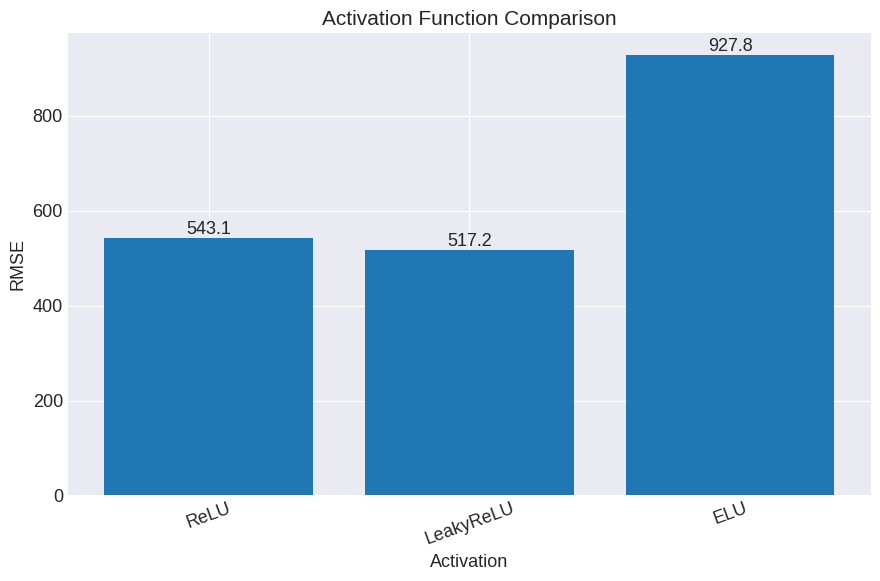

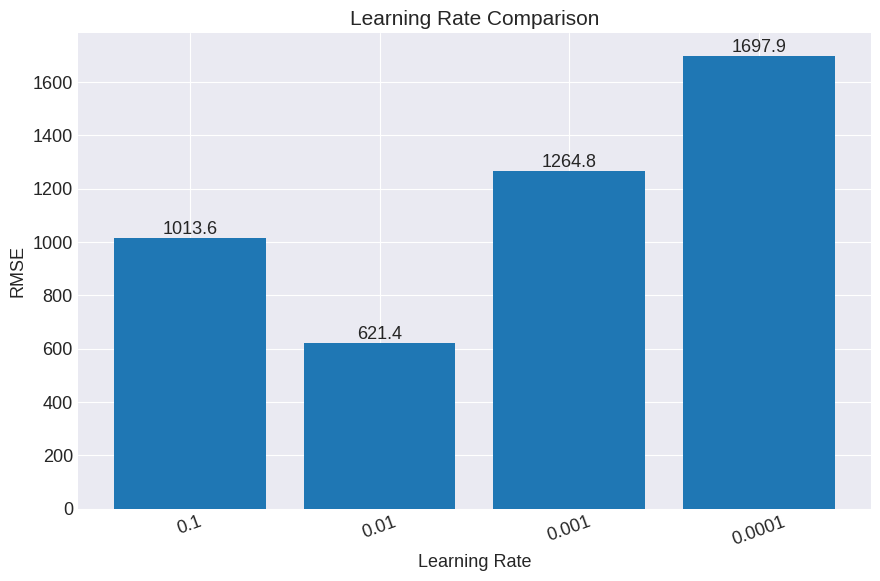

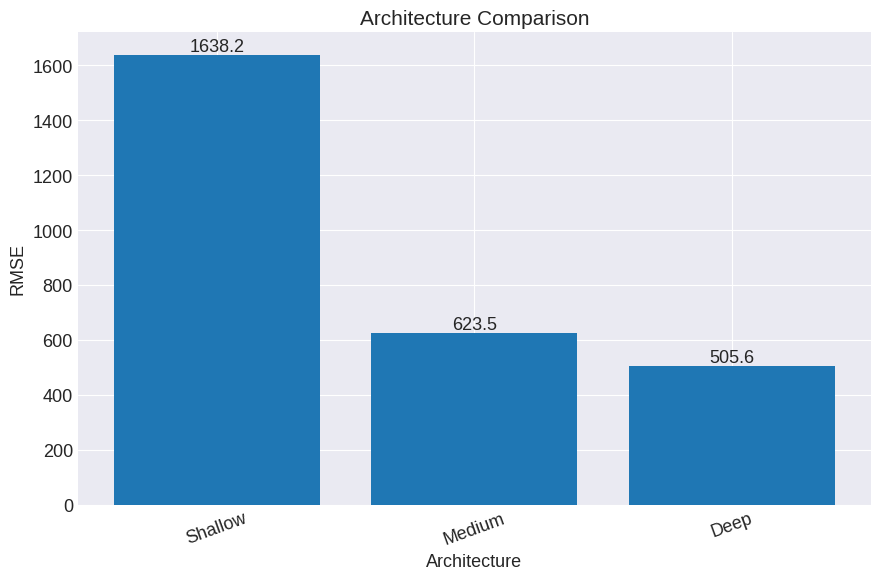

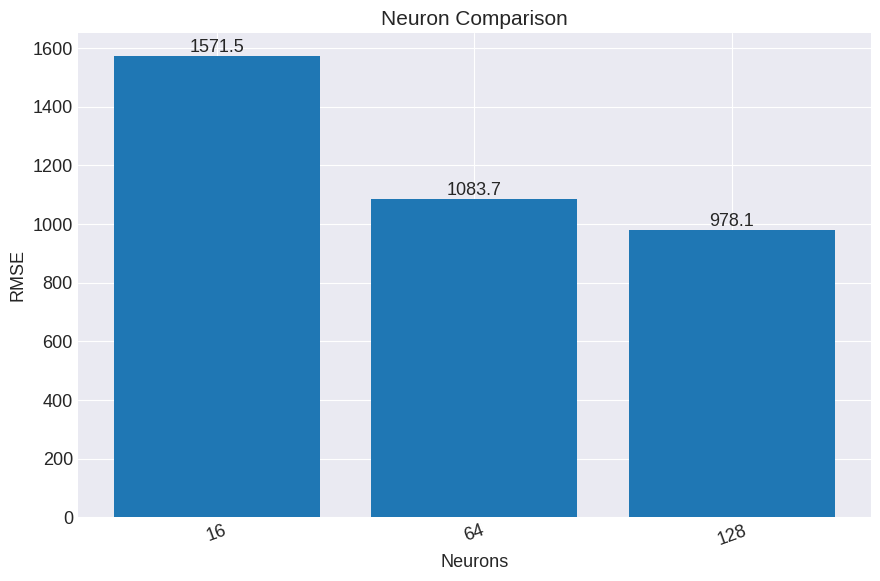

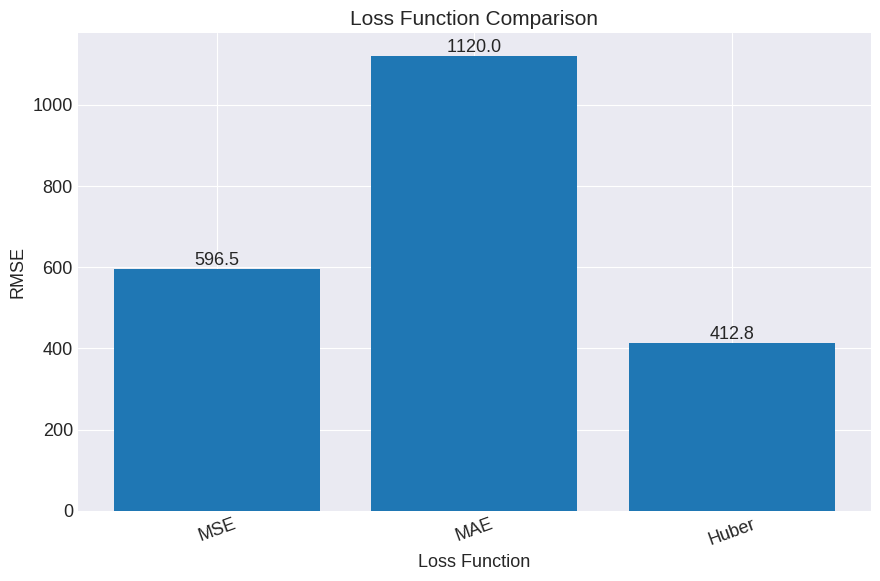

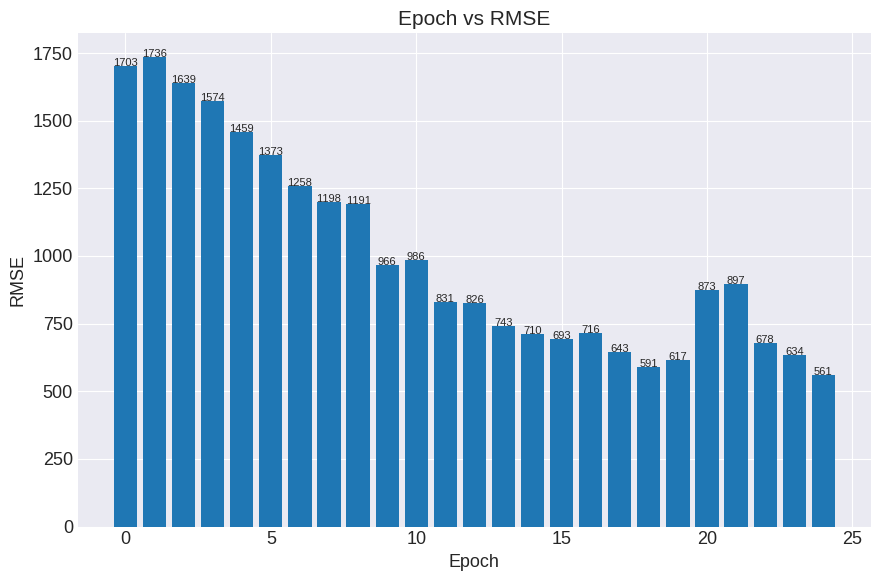

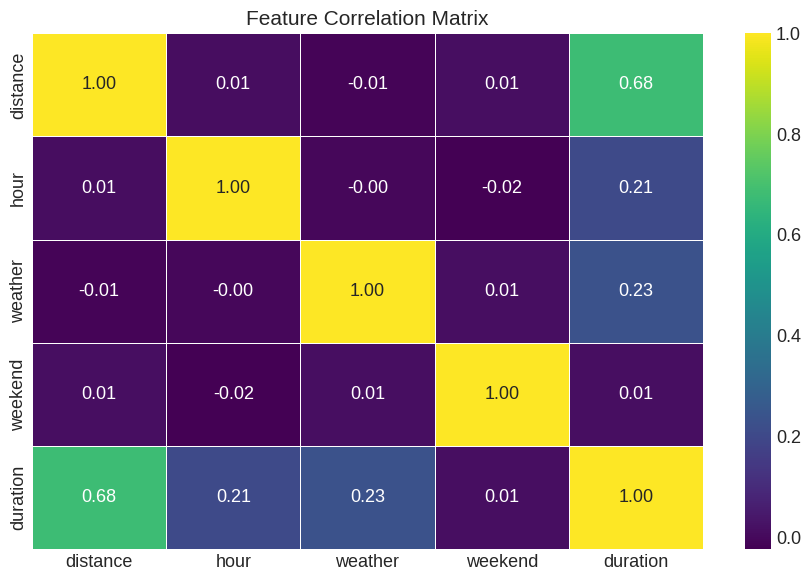


📊 Numerical Results:


Activation Functions
   Parameter        RMSE
1  LeakyReLU  517.184255
0       ReLU  543.086526
2        ELU  927.814067
🏆 Best: LeakyReLU (RMSE=517.18)

Learning Rates
  Parameter         RMSE
1      0.01   621.448010
0       0.1  1013.584222
2     0.001  1264.788608
3    0.0001  1697.889728
🏆 Best: 0.01 (RMSE=621.45)

Architectures
  Parameter         RMSE
2      Deep   505.591258
1    Medium   623.515155
0   Shallow  1638.170373
🏆 Best: Deep (RMSE=505.59)

Neurons
  Parameter         RMSE
2       128   978.073255
1        64  1083.698862
0        16  1571.542248
🏆 Best: 128 (RMSE=978.07)

Loss Functions
  Parameter         RMSE
2     Huber   412.842377
0       MSE   596.460297
1       MAE  1120.018926
🏆 Best: Huber (RMSE=412.84)

================ FINAL BEST CONFIG =================
Activation     : LeakyReLU
Learning Rate  : 0.01
Architecture   : Deep
Neurons        : 128
Loss Function  : Huber

✅ Research Pipeline Completed Successfully!


In [ ]:

#for bus eta regression problem



import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset



print("🚀 Running Full AI Research Pipeline...")

# ==========================================
# 🎨 VISUAL STYLE (IMPROVED)
# ==========================================
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    "font.size": 13,
    "figure.figsize": (9,6),
    "axes.titlesize": 15,
    "axes.labelsize": 13,
})

# ==========================================
# 📊 NICE BAR PLOT FUNCTION
# ==========================================
def nice_bar_plot(data, title, xlabel, ylabel):
    labels = list(data.keys())
    values = list(data.values())

    plt.figure()
    bars = plt.bar(labels, values)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval,
                 f'{yval:.1f}', ha='center', va='bottom')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# ==========================================
# 1. DATA GENERATION
# ==========================================
np.random.seed(42)
num_samples = 5000

dist = np.random.uniform(2, 40, num_samples)
hour = np.random.randint(0, 24, num_samples)
weather = np.random.choice([0,1,2], num_samples)
weekend = np.random.choice([0,1], num_samples, p=[0.7,0.3])

base = (dist / 40) * 3600

traffic = np.ones(num_samples)
traffic[(hour >= 9) & (hour <= 11)] = 2.2
traffic[(hour >= 17) & (hour <= 20)] = 2.5

weather_delay = np.ones(num_samples)
weather_delay[weather == 1] = 1.3
weather_delay[weather == 2] = 1.6

noise = np.random.normal(1, 0.1, num_samples)

y = base * traffic * weather_delay * noise

df = pd.DataFrame({
    "distance": dist,
    "hour": hour,
    "weather": weather,
    "weekend": weekend,
    "duration": y
})

# ==========================================
# 2. PREPROCESSING
# ==========================================
X = df[['distance','hour','weather','weekend']].values
y = df['duration'].values.reshape(-1,1)

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2)

sx, sy = StandardScaler(), StandardScaler()

X_train = torch.tensor(sx.fit_transform(X_train), dtype=torch.float32)
X_val = torch.tensor(sx.transform(X_val), dtype=torch.float32)
y_train = torch.tensor(sy.fit_transform(y_train), dtype=torch.float32)
y_val = torch.tensor(sy.transform(y_val), dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train,y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val,y_val), batch_size=64)

input_dim = X_train.shape[1]

# ==========================================
# 3. MODEL FUNCTION
# ==========================================
def run_model(layers, activation, lr, loss_fn, epochs=25):

    net = []
    in_dim = input_dim

    for l in layers:
        net.append(nn.Linear(in_dim, l))
        net.append(activation())
        in_dim = l

    net.append(nn.Linear(in_dim, 1))
    model = nn.Sequential(*net)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = loss_fn

    history = []

    for _ in range(epochs):
        model.train()
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        total = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                total += criterion(model(Xb), yb).item() * Xb.size(0)

        mse = total / len(val_loader.dataset)
        rmse = math.sqrt(mse) * sy.scale_[0]
        history.append(rmse)

    return history

# ==========================================
# 4. ACTIVATION
# ==========================================
activations = {
    "ReLU": nn.ReLU,
    "LeakyReLU": nn.LeakyReLU,
    "ELU": nn.ELU
}

act_results = {}

for name, act in activations.items():
    hist = run_model([64,32], act, 0.01, nn.MSELoss())
    act_results[name] = hist[-1]

nice_bar_plot(act_results, "Activation Function Comparison", "Activation", "RMSE")

# ==========================================
# 5. LEARNING RATE
# ==========================================
lrs = [0.1, 0.01, 0.001, 0.0001]
lr_results = {}

for lr in lrs:
    hist = run_model([64,32], nn.ReLU, lr, nn.MSELoss())
    lr_results[str(lr)] = hist[-1]

nice_bar_plot(lr_results, "Learning Rate Comparison", "Learning Rate", "RMSE")

# ==========================================
# 6. ARCHITECTURE
# ==========================================
architectures = {
    "Shallow": [8],
    "Medium": [64,32],
    "Deep": [128,64,32,16]
}

arch_results = {}

for name, cfg in architectures.items():
    hist = run_model(cfg, nn.ReLU, 0.01, nn.MSELoss())
    arch_results[name] = hist[-1]

nice_bar_plot(arch_results, "Architecture Comparison", "Architecture", "RMSE")

# ==========================================
# 7. NEURONS
# ==========================================
neurons = {
    "16": [16],
    "64": [64],
    "128": [128]
}

neuron_results = {}

for name, cfg in neurons.items():
    hist = run_model(cfg, nn.ReLU, 0.01, nn.MSELoss())
    neuron_results[name] = hist[-1]

nice_bar_plot(neuron_results, "Neuron Comparison", "Neurons", "RMSE")

# ==========================================
# 8. LOSS FUNCTION
# ==========================================
losses = {
    "MSE": nn.MSELoss(),
    "MAE": nn.L1Loss(),
    "Huber": nn.SmoothL1Loss()
}

loss_results = {}

for name, loss_fn in losses.items():
    hist = run_model([64,32], nn.ReLU, 0.01, loss_fn)
    loss_results[name] = hist[-1]

nice_bar_plot(loss_results, "Loss Function Comparison", "Loss Function", "RMSE")

# ==========================================
# 9. EPOCH GRAPH (IMPROVED)
# ==========================================
history = run_model([64,32], nn.ReLU, 0.01, nn.MSELoss())

plt.figure()
bars = plt.bar(range(len(history)), history)

for i, v in enumerate(history):
    plt.text(i, v, f"{v:.0f}", ha='center', fontsize=8)

plt.title("Epoch vs RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

# ==========================================
# 10. HEATMAP
# ==========================================
plt.figure(figsize=(9,6))
sns.heatmap(df.corr(), annot=True, cmap="viridis", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# ==========================================
# 🔢 NUMERICAL RESULTS
# ==========================================
print("\n📊 Numerical Results:\n")

def display_results(title, results):
    df_res = pd.DataFrame(list(results.items()), columns=["Parameter", "RMSE"])
    df_res = df_res.sort_values(by="RMSE")
    print(f"\n{title}")
    print(df_res)
    print(f"🏆 Best: {df_res.iloc[0]['Parameter']} (RMSE={df_res.iloc[0]['RMSE']:.2f})")
    return df_res.iloc[0]['Parameter']

best_act = display_results("Activation Functions", act_results)
best_lr = display_results("Learning Rates", lr_results)
best_arch = display_results("Architectures", arch_results)
best_neuron = display_results("Neurons", neuron_results)
best_loss = display_results("Loss Functions", loss_results)

# ==========================================
# 🏆 FINAL SUMMARY
# ==========================================
print("\n================ FINAL BEST CONFIG =================")
print(f"Activation     : {best_act}")
print(f"Learning Rate  : {best_lr}")
print(f"Architecture   : {best_arch}")
print(f"Neurons        : {best_neuron}")
print(f"Loss Function  : {best_loss}")
print("===================================================")

print("\n✅ Research Pipeline Completed Successfully!")